TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mNo implementation of function Function(<built-in function setitem>) found for signature:
 
 >>> setitem(array(undefined, 1d, C), int64, array(float64, 2d, C))
 
There are 16 candidate implementations:
[1m   - Of which 16 did not match due to:
   Overload of function 'setitem': File: <numerous>: Line N/A.
     With argument(s): '(array(undefined, 1d, C), int64, array(float64, 2d, C))':[0m
[1m    No match.[0m
[0m
[0m[1mDuring: typing of setitem at C:\Users\toima\PycharmProjects\Neuronensimulation\aufgabe2\ode_solver_runge_kutta.py (47)[0m
[1m
File "..\..\aufgabe2\ode_solver_runge_kutta.py", line 47:[0m
[1mdef runge_kutta_method_matrix(x_0 : np.ndarray, time_array : np.ndarray, dt : float, eigen_current :np.ndarray, weights_matrix: np.ndarray, tuple_of_constants : tuple) -> np.ndarray:
    <source elided>
    for t in time_array:
[1m        values_of_functions.append(x)
[0m        [1m^[0m[0

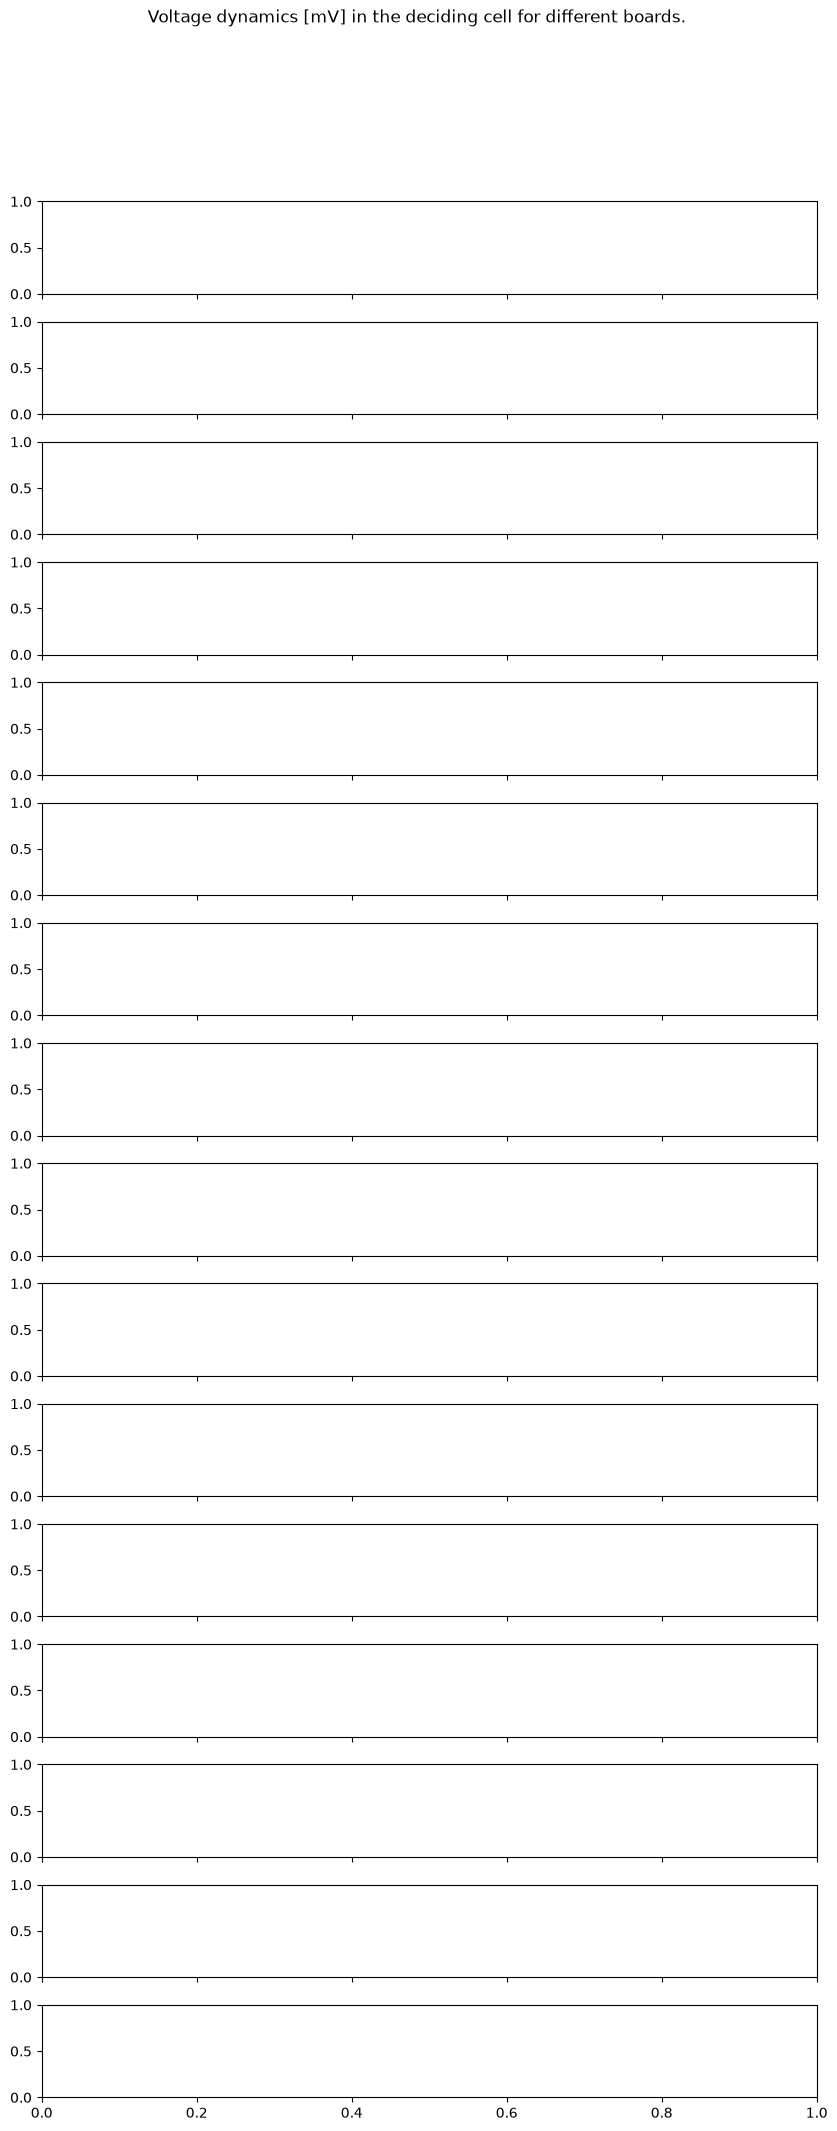

In [1]:
import numpy as np

from aufgabe3 import set_of_boards
from aufgabe3.nn import NN
import matplotlib.pyplot as plt


w = 0.07
weights = w * np.array([1, - 1, 1, -1, -1, 1])
network = NN(weights, 2, 2)
board = np.array([[1,0],[0,1]])
boards = set_of_boards.get_set_of_boards()

tpoints = network.time_array

fig, ax = plt.subplots(len(boards), 1, figsize=(10, 24), sharex=True)
ax = ax.flatten()
fig.suptitle("Voltage dynamics [mV] in the deciding cell for different boards.")
fig.subplots_adjust(top=0.9, hspace=0.3)

i = 0

for b in boards:
    network.input_board(b)
    voltage = network.get_deciding_neuron_voltage()
    voltage_max = round(voltage.max(),2)
    voltage_mean = round(voltage.mean(), 2)
    board_label = (f"Board:\n{'▣' if b[0,0]== 1 else '▢'} {'▣' if b[0,1]== 1 else '▢'} \n{'▣' if b[1,0]== 1 else '▢'} {'▣' if b[1,1]== 1 else '▢'} \n"
                   + r"$V_{max}$ = " + f"{voltage_max}, " +r"$V_{mean}$ = " + f"{voltage_mean}")
    ax[i].plot(tpoints, voltage, label = board_label)
    ax[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
    i += 1

ax[-1].set_xlabel("Time (ms)")

plt.show()
